# 05 - Risk Book, VaR, and Stress Testing

Purpose:
- build the benchmark commodity risk book;
- compute conventional historical-simulation VaR and ES;
- create stress-test scenarios that can be triggered by the gold alarm;
- keep Copper as a robustness extension rather than part of the primary book.

Core design:
The primary risk book is Brent-only for now. This keeps the early-warning test focused: does the gold alarm prompt review before traditional Brent-book risk measures fully react? Copper can be introduced later as a diversified commodity-book robustness extension.

## Reader Orientation

This notebook creates the risk-control response layer. The Gold alarm has value only if it connects to a risk action. Here, the action is to compare the alarm against conventional Brent-book VaR and run stress scenarios when the dashboard state is elevated.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "step05"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
market_vars_path = PROCESSED_DIR / "market_vars_core.parquet"
if not market_vars_path.exists():
    market_vars_path = PROCESSED_DIR / "market_vars.parquet"

alarm_frame_path = PROCESSED_DIR / "gold_alarm_frame.parquet"

market_vars = pd.read_parquet(market_vars_path)
alarm_frame = pd.read_parquet(alarm_frame_path)

if "r_Brent" not in market_vars.columns:
    raise ValueError("Step 05 requires r_Brent from Step 02")
if "gold_alarm" not in alarm_frame.columns:
    raise ValueError("Step 05 requires gold_alarm from Step 04")

print("Market vars:", market_vars_path, market_vars.shape)
print("Alarm frame:", alarm_frame_path, alarm_frame.shape)


Market vars: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\data\processed\market_vars_core.parquet (4090, 5)
Alarm frame: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\data\processed\gold_alarm_frame.parquet (4090, 6)


In [3]:
NAV0 = 100.0
VAR_CONFIDENCE = 0.95
VAR_ALPHA = 1 - VAR_CONFIDENCE
VAR_WINDOW = 250
REALIZED_VOL_WINDOW = 20
DRAWDOWN_EVENT_LEVEL = -0.05

# Primary benchmark book: Brent-only for the main test.
# Copper remains a robustness extension, not part of this primary result.
WEIGHT_BRENT = 1.00


### Why The Primary Book Is Brent-Only

The core test stays Brent-only to avoid making the first result depend on a new asset choice. Copper is economically useful for a diversified commodity book, but it belongs in robustness after the main Brent-focused signal is evaluated. This keeps the project's empirical claim narrower and easier to defend.

## Benchmark Risk Book

The benchmark book is deliberately simple. It is not a portfolio-construction exercise; it is a conventional risk-measure baseline against which the gold alarm can be evaluated.

In [4]:
riskbook = pd.DataFrame(index=market_vars.index)
riskbook["R_book"] = WEIGHT_BRENT * market_vars["r_Brent"]
riskbook["nav"] = NAV0 * (1 + riskbook["R_book"]).cumprod()
riskbook["drawdown"] = riskbook["nav"] / riskbook["nav"].cummax() - 1
riskbook["realized_vol_20d"] = riskbook["R_book"].rolling(REALIZED_VOL_WINDOW).std() * np.sqrt(252)

riskbook = riskbook.join(
    alarm_frame[["gold_alarm", "alarm_score", "dashboard_state"]],
    how="left",
)

riskbook.tail()


,R_book,nav,drawdown,realized_vol_20d,gold_alarm,alarm_score,dashboard_state
Date,,,,,,,
2026-05-26,-0.038997,40.279864,-0.733383,0.623301,0,1,Amber
2026-05-27,-0.054586,38.081139,-0.747937,0.635885,0,1,Amber
2026-05-28,-0.006170,37.846169,-0.749492,0.584325,0,1,Amber
2026-05-29,-0.017873,37.169746,-0.753969,0.578528,0,1,Amber
2026-06-01,0.031334,38.334439,-0.746260,0.574621,0,1,Amber


### Result Comment And Significance

This table creates the conventional risk-book baseline: book return, NAV, drawdown, realized volatility, and gold alarm state. The goal is not to optimize the book; it is to create a traditional risk measure that can be compared against the gold alarm's timing.

## Historical Simulation VaR and ES

VaR is computed using prior returns only. The current day's return is not included in the current day's VaR estimate.

In [5]:
hist_input = riskbook["R_book"].shift(1)

riskbook["hs_var_return"] = hist_input.rolling(VAR_WINDOW).quantile(VAR_ALPHA)
riskbook["hs_es_return"] = hist_input.rolling(VAR_WINDOW).apply(
    lambda x: x[x <= np.quantile(x, VAR_ALPHA)].mean(),
    raw=True,
)

riskbook["var_breach"] = (riskbook["R_book"] < riskbook["hs_var_return"]).astype(int)
riskbook["excess_loss_over_var"] = riskbook["hs_var_return"] - riskbook["R_book"]

coverage_sample = riskbook.dropna(subset=["hs_var_return"])
coverage_summary = pd.DataFrame([{
    "book": "core_brent",
    "var_confidence": VAR_CONFIDENCE,
    "expected_breach_rate": VAR_ALPHA,
    "observed_breach_rate": coverage_sample["var_breach"].mean(),
    "breach_count": int(coverage_sample["var_breach"].sum()),
    "sample_days": len(coverage_sample),
    "max_drawdown": riskbook["drawdown"].min(),
}])

coverage_summary


,book,var_confidence,expected_breach_rate,observed_breach_rate,breach_count,sample_days,max_drawdown
0,core_brent,0.95,0.05,0.057813,222,3840,-0.917441


### Result Comment And Significance

The latest core Brent VaR result has an observed breach rate around 5.78% versus the expected 5.00%. That is close but not perfect, which is realistic for historical simulation VaR. The max drawdown is very large, around -91.7%, showing why the book needs stress testing and why trailing VaR alone may be slow during severe commodity regimes.

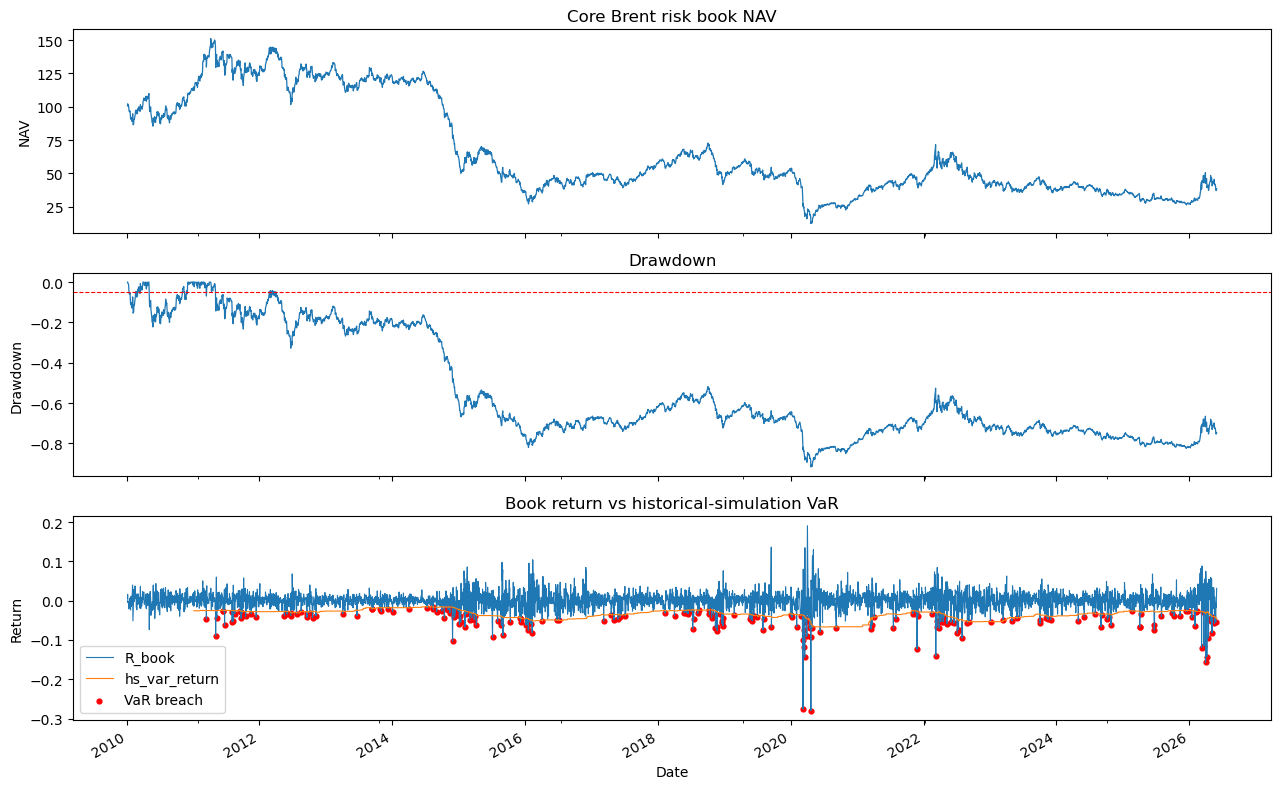

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

riskbook["nav"].plot(ax=axes[0], linewidth=0.9)
axes[0].set_title("Core Brent risk book NAV")
axes[0].set_ylabel("NAV")

riskbook["drawdown"].plot(ax=axes[1], linewidth=0.9)
axes[1].axhline(DRAWDOWN_EVENT_LEVEL, color="red", linestyle="--", linewidth=0.8)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")

riskbook[["R_book", "hs_var_return"]].plot(ax=axes[2], linewidth=0.8)
axes[2].scatter(
    riskbook.index[riskbook["var_breach"] == 1],
    riskbook.loc[riskbook["var_breach"] == 1, "R_book"],
    s=12,
    color="red",
    label="VaR breach",
)
axes[2].legend()
axes[2].set_title("Book return vs historical-simulation VaR")
axes[2].set_ylabel("Return")

plt.tight_layout()


## Gold-Triggered Stress Scenarios

These scenarios are intentionally stylized. They translate the alarm into operational risk action: if the gold alarm is Red, review VaR and run stress tests.

### How This Supports The Project Premise

The warning system becomes useful only when it changes risk-manager behaviour. The stress scenarios define what the user should do after a Red alarm. This makes the dashboard operational rather than just descriptive.

In [7]:
stress_scenarios = pd.DataFrame([
    {
        "scenario": "Risk-off growth shock",
        "r_Brent": -0.08,
        "r_Gold": 0.03,
        "r_DXY": 0.02,
        "d_VIX": 12.0,
        "d_US10Y": -0.20,
        "description": "Demand shock: Brent falls while gold, USD, and VIX rise.",
    },
    {
        "scenario": "Geopolitical inflation shock",
        "r_Brent": 0.10,
        "r_Gold": 0.04,
        "r_DXY": 0.01,
        "d_VIX": 8.0,
        "d_US10Y": 0.10,
        "description": "Supply-risk shock: Brent and gold rally together.",
    },
    {
        "scenario": "Liquidity liquidation shock",
        "r_Brent": -0.06,
        "r_Gold": -0.04,
        "r_DXY": 0.03,
        "d_VIX": 15.0,
        "d_US10Y": -0.30,
        "description": "Cash scramble: Brent and gold sell off together.",
    },
    {
        "scenario": "Monetary tightening shock",
        "r_Brent": -0.03,
        "r_Gold": -0.05,
        "r_DXY": 0.04,
        "d_VIX": 5.0,
        "d_US10Y": 0.35,
        "description": "Higher real-rate/USD shock pressures gold and Brent.",
    },
])

stress_scenarios["book_return"] = WEIGHT_BRENT * stress_scenarios["r_Brent"]
stress_scenarios["book_pnl_on_nav100"] = stress_scenarios["book_return"] * NAV0
stress_scenarios


,scenario,r_Brent,r_Gold,r_DXY,d_VIX,d_US10Y,description,book_return,book_pnl_on_nav100
0,Risk-off growth shock,-0.08,0.03,0.02,12.0,-0.20,"Demand shock: Brent falls while gold, USD, and...",-0.08,-8.0
1,Geopolitical inflation shock,0.10,0.04,0.01,8.0,0.10,Supply-risk shock: Brent and gold rally together.,0.10,10.0
2,Liquidity liquidation shock,-0.06,-0.04,0.03,15.0,-0.30,Cash scramble: Brent and gold sell off together.,-0.06,-6.0
3,Monetary tightening shock,-0.03,-0.05,0.04,5.0,0.35,Higher real-rate/USD shock pressures gold and ...,-0.03,-3.0


### Why Stress Scenarios Are Included

The dashboard should not only warn users; it should tell them what risk action to take. These scenarios translate a Red alarm into concrete stress tests: growth shock, geopolitical inflation shock, liquidity liquidation, and monetary tightening. This turns gold abnormality into an operational risk workflow.

## Optional Copper Robustness Book

This section is optional. If Step 02 produced `market_vars_robustness.parquet`, compare the core Brent book against a diversified Brent/Copper book. This is not the primary result.

In [8]:
robustness_path = PROCESSED_DIR / "market_vars_robustness.parquet"
robustness_summary = pd.DataFrame()
robustness_riskbook = pd.DataFrame()

if robustness_path.exists():
    robustness_vars = pd.read_parquet(robustness_path)
    if {"r_Brent", "r_Copper"}.issubset(robustness_vars.columns):
        robustness_riskbook = pd.DataFrame(index=robustness_vars.index)
        robustness_riskbook["R_book"] = 0.50 * robustness_vars["r_Brent"] + 0.50 * robustness_vars["r_Copper"]
        robustness_riskbook["nav"] = NAV0 * (1 + robustness_riskbook["R_book"]).cumprod()
        robustness_riskbook["drawdown"] = robustness_riskbook["nav"] / robustness_riskbook["nav"].cummax() - 1
        hist_input_robust = robustness_riskbook["R_book"].shift(1)
        robustness_riskbook["hs_var_return"] = hist_input_robust.rolling(VAR_WINDOW).quantile(VAR_ALPHA)
        robustness_riskbook["var_breach"] = (robustness_riskbook["R_book"] < robustness_riskbook["hs_var_return"]).astype(int)
        sample = robustness_riskbook.dropna(subset=["hs_var_return"])
        robustness_summary = pd.DataFrame([{
            "book": "robustness_brent_copper_50_50",
            "observed_breach_rate": sample["var_breach"].mean(),
            "breach_count": int(sample["var_breach"].sum()),
            "sample_days": len(sample),
            "max_drawdown": robustness_riskbook["drawdown"].min(),
        }])

robustness_summary


,book,observed_breach_rate,breach_count,sample_days,max_drawdown
0,robustness_brent_copper_50_50,0.057292,220,3840,-0.784568


### Result Comment And Significance

The latest optional Brent/Copper robustness book has a similar VaR breach rate, around 5.73%, but a less severe max drawdown, around -78.5%. That suggests diversification changes loss severity more than VaR coverage. This supports keeping Copper as a robustness extension rather than the main book for the first result.

## Step 05 Working Takeaways

- The primary risk-book baseline is Brent-only.
- Copper is kept as an optional diversified-book robustness extension.
- VaR uses prior returns only.
- Stress scenarios provide the operational action layer triggered by alarm severity.

In [9]:
riskbook.to_parquet(PROCESSED_DIR / "riskbook_var_core.parquet")
# Compatibility alias for Step 06.
riskbook.to_parquet(PROCESSED_DIR / "riskbook_var.parquet")

coverage_summary.to_csv(OUTPUT_DIR / "var_coverage_summary_core.csv", index=False)
stress_scenarios.to_csv(OUTPUT_DIR / "stress_scenarios_core.csv", index=False)

if not robustness_riskbook.empty:
    robustness_riskbook.to_parquet(PROCESSED_DIR / "riskbook_var_robustness.parquet")
if not robustness_summary.empty:
    robustness_summary.to_csv(OUTPUT_DIR / "var_coverage_summary_robustness.csv", index=False)

print("Saved Step 05 risk-book, VaR, and stress-test outputs to:", OUTPUT_DIR)


Saved Step 05 risk-book, VaR, and stress-test outputs to: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\outputs\step05
